##Acquisition

In [ ]:
! git clone https://github.com/vrdn-23/SemEval-2020

Cloning into 'SemEval-2020'...
remote: Enumerating objects: 2268, done.
remote: Counting objects: 100% (2268/2268), done.
remote: Compressing objects: 100% (1494/1494), done.
remote: Total 2268 (delta 735), reused 2200 (delta 695), pack-reused 0 (from 0)
Receiving objects: 100% (2268/2268), 9.97 MiB | 9.74 MiB/s, done.
Resolving deltas: 100% (735/735), done.


###Before Tokenizer

In [ ]:
a = open("/content/SemEval-2020/datasets/train-articles/article111111111.txt", 'r').read()
a[265:323]
a[1795:1935]
a[149:157]
a[1069:1091]

'a very, very different'

In [ ]:
def load_spans(text):
  text = text.strip().split('\n')
  # print(text)
  output = [{"loc": (int(start), int(end)),
             "propType": sorted(pType.split(','))} for (article, pType, start, end) in sorted(list(map(lambda x: x.split('\t'), text)), key= lambda x: int(x[2]))] if text[0] else []
  return output

In [ ]:
from pathlib import Path

folder = Path("/content/SemEval-2020/datasets")
texts_folder = Path("/content/SemEval-2020/datasets/train-articles")
spans_folder = Path("/content/SemEval-2020/datasets/train-labels-task2-technique-classification")

dataset = []

for text_file in texts_folder.glob('*'):
    span_file = spans_folder / (text_file.stem + ".task2-TC.labels")

    text = text_file.read_text(encoding="utf-8")
    spans = load_spans(span_file.read_text(encoding="utf-8"))

    dataset.append({
        "text": text,
        "spans": spans
    })

In [ ]:
len(dataset)
dataset[31]

{'text': "La Stampa’s Robert Fastiggi Replies to Chris Ferrara\n\nLa Stampa’s Robert Fastiggi Replied to Chris Ferrara’s articles on Fastiggi and Goldstein’s defense of Amoris Laetitia and their criticism of the Filial Correction:\n\n\nFastiggi’s exchange with Ferrara concerning “Wait, Wait, It’s all a mistranslation!”\n\nRobert Fastiggi • 13 hours ago\n\nIn the article that I co-authored with Dr. Goldstein, we would have done better to speak of the “official” Latin text rather than the “original” Latin text.\nThis, though, is no longer an issue because the normative text is the Latin text published in thr AAS.\nMr. Ferrara, however, bases his critique upon an assumption that the “generous response” offered to God is a sin.\nThis, though, is not what AL is saying.\nThe generous response is a move away from sin and a move toward God.\nI explain this in my most recent response to Prof. E. Christian Brugger, which can serve as my response to Mr. Ferrara:\n\nPosted on LifeSiteNews:\nProf. 

#Subtask2

In [ ]:
HALF_LENGTH = 200
dataset_TC = []
X = []
y = []
propagandas = set()
for text, spans in [(a['text'], a['spans']) for a in dataset]:
  if spans:
    for span in spans:
      start, end = span['loc']
      start = start - HALF_LENGTH if start>HALF_LENGTH else 0
      end += HALF_LENGTH
      text_cut = text[start:end]
      if start!=0:
        text_cut = text_cut[text_cut.index(' ')+1:]
      if end!=len(text):
        text_cut = text_cut[:text_cut[::-1].index(' ')*-1 - 1]
      dataset_TC.append({
          "text": text_cut,
          'span': text[span['loc'][0]:span['loc'][1]],
          'type': span['propType'][0]
      })
      # if span['propType']:
      #   print(span['propType'])
      propagandas.add(span['propType'][0])
      X.append((dataset_TC[-1]['text'], dataset_TC[-1]['span']))
      y.append(dataset_TC[-1]['type'])


In [ ]:
propagandas

{'Appeal_to_Authority',
 'Appeal_to_fear-prejudice',
 'Bandwagon',
 'Black-and-White_Fallacy',
 'Causal_Oversimplification',
 'Doubt',
 'Exaggeration',
 'Flag-Waving',
 'Labeling',
 'Loaded_Language',
 'Red_Herring',
 'Repetition',
 'Slogans',
 'Thought-terminating_Cliches'}

In [ ]:
X[11]

("Francis and Farrell’s 'Sinod' on the Youth, #StopThe Synod2018\n\nDuring the last 5 years of this papacy, Francis and his Synodal Schemers masterfully manipulated, rigged, and exploited the synodal process.\nThe backdoor tactics and machinations were brilliantly documented by Edward Pentin , Henry Sire, George Neumayr and an array of investigative",
 'manipulated')

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_ds = Dataset.from_dict({
    "text": [item[0] for item in X_train],
    "span": [item[1] for item in X_train],
    "label": y_train
})

val_ds = Dataset.from_dict({
    "text": [item[0] for item in X_test],
    "span": [item[1] for item in X_test],
    "label": y_test
})

dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds
})

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"

In [ ]:
import torch

from typing import Optional, Union, List
import torch.nn as nn
from transformers.models.qwen2 import Qwen2PreTrainedModel, Qwen2Model
from transformers.modeling_outputs import SequenceClassifierOutput

class Qwen2LastForSequenceClassification(Qwen2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config

        self.model = Qwen2Model(config)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels, bias=False)
        print("Before post_init", config.num_labels)
        # Initialize weights and apply final processing
        self.post_init()
        print("After post_init", config.num_labels)

    def forward(
        self,
        input_ids: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_values: Optional[List[torch.FloatTensor]] = None,
        inputs_embeds: Optional[torch.FloatTensor] = None,
        labels: Optional[torch.LongTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None
    ) -> Union[tuple[torch.Tensor], SequenceClassifierOutput]:
        r"""
        token_type_ids (`torch.LongTensor` of shape `(batch_size, sequence_length)`, *optional*):
            Segment token indices to indicate first and second portions of the inputs. Indices are selected in `[0,1]`:

            - 0 corresponds to a *sentence A* token,
            - 1 corresponds to a *sentence B* token.
            This parameter can only be used when the model is initialized with `type_vocab_size` parameter with value
            >= 2. All the value in this tensor should be always < type_vocab_size.

            [What are token type IDs?](../glossary#token-type-ids)
        labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
            Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
            config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
            `config.num_labels > 1` a classification loss is computed (Cross-Entropy).
        """
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            inputs_embeds=inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        sequence_output = outputs[0][:,-1]
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            # move labels to correct device to enable model parallelism
            labels = labels.to(logits.device)
            if self.config.problem_type is None:
                if self.num_labels == 1:
                    self.config.problem_type = "regression"
                elif self.num_labels > 1 and (labels.dtype == torch.long or labels.dtype == torch.int):
                    self.config.problem_type = "single_label_classification"
                else:
                    self.config.problem_type = "multi_label_classification"

            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

cls = Qwen2LastForSequenceClassification.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", num_labels=14).to("cuda")

In [ ]:
class ChatDatasetFormatter:

    def __init__(self, tokenizer, pattern, system_pattern=None,
                 label_mapping=None, label_field="label", use_label=False):
        self.tokenizer = tokenizer
        self.pattern = pattern
        self.system_pattern = system_pattern
        self.label_mapping = label_mapping or dict()
        self.label_field = label_field
        self.use_label = use_label

    def __call__(self, item):
        text = self.pattern.format(**item)
        if self.system_pattern is None:
            messages = [{"role": "user", "content": text}]
        else:
            messages = [{"role": "system", "content": self.system_pattern},
                        {"role": "user", "content": text}]

        input_ids = self.tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=True)
        attention_mask = [1] * len(input_ids)

        label_str = item[self.label_field]
        label_idx = self.label_mapping[label_str]

        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": label_idx}

system_pattern = """You are an expert in linguistics and propaganda classification. Your task is to analyze the given text fragment and classify the propaganda piece given below.
You have the following options:
- Loaded Language
- Name calling
- Repetition
- Exaggeration
- Doubt
- Appeal to fear
- Flag-waving
- Causal oversimplification
- Slogans
- Appeal to authority
- Black-and-white fallacy
- Thought-terminating cliché
- Whataboutism
- Bandwagon
"""
user_pattern = """Text:
{text}
Propaganda:
{span}"""

PROPAGANDA_CLASSES = [
    'Appeal_to_Authority', 'Appeal_to_fear-prejudice', 'Bandwagon',
    'Black-and-White_Fallacy', 'Causal_Oversimplification', 'Doubt',
    'Exaggeration', 'Flag-Waving', 'Labeling', 'Loaded_Language',
    'Red_Herring', 'Repetition', 'Slogans', 'Thought-terminating_Cliches'
]

label_to_id = {name: i for i, name in enumerate(PROPAGANDA_CLASSES)}


dataset_formatter = ChatDatasetFormatter(
    tokenizer, system_pattern=system_pattern, pattern=user_pattern,
    label_mapping=label_to_id
)

column_names = dataset["train"].column_names
train_dataset_mapped = dataset["train"].map(
    dataset_formatter,
    remove_columns=column_names,
    desc="Mapping train dataset"
)

validation_dataset_mapped = dataset["validation"].map(
    dataset_formatter,
    remove_columns=column_names,
    desc="Mapping validation dataset"
)


#Lorica segmentata

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from transformers import DataCollatorWithPadding
from tqdm.auto import tqdm

cls.eval()

data_collator = DataCollatorWithPadding(tokenizer, return_tensors="pt")

BATCH_SIZE = 8
pred_logits = []
corr_labels = []

for start in tqdm(range(0, len(validation_dataset_mapped), BATCH_SIZE), desc="Zero-Shot Eval"):
    samples = [validation_dataset_mapped[i]
               for i in range(start, min(start + BATCH_SIZE, len(validation_dataset_mapped)))]

    batch = data_collator(samples)

    batch = {k: v.to(lora_model.device) for k, v in batch.items()}

    with torch.no_grad():
        outputs = cls(**batch)
        logits = outputs.logits

    pred_logits.extend(logits.cpu().numpy())
    corr_labels.extend(batch["labels"].cpu().numpy())

pred_probs = np.array(pred_logits)
pred_labels = np.argmax(pred_probs, axis=-1)

print(f"Zero-Shot Accuracy: {accuracy_score(corr_labels, pred_labels):.4f}")
print("\nClassification Report:")

print(classification_report(
    corr_labels,
    pred_labels,
    target_names=PROPAGANDA_CLASSES,
    zero_division=0
))

Zero-Shot Eval:   0%|          | 0/154 [00:00<?, ?it/s]

Zero-Shot Accuracy: 0.1501

Classification Report:
                             precision    recall  f1-score   support

        Appeal_to_Authority       0.00      0.00      0.00        25
   Appeal_to_fear-prejudice       0.00      0.00      0.00        54
                  Bandwagon       0.00      0.00      0.00        15
    Black-and-White_Fallacy       0.00      0.00      0.00        26
  Causal_Oversimplification       0.00      0.00      0.00        33
                      Doubt       0.00      0.00      0.00       111
               Exaggeration       0.00      0.00      0.00       105
                Flag-Waving       0.00      0.00      0.00        43
                   Labeling       0.14      0.84      0.24       183
            Loaded_Language       0.33      0.07      0.12       437
                Red_Herring       0.00      0.00      0.00        20
                 Repetition       0.00      0.00      0.00       143
                    Slogans       0.00      0.00   

#Lorica squamata

In [ ]:
import torch

from transformers import BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

lora_model = Qwen2LastForSequenceClassification.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    num_labels=14,
    quantization_config=bnb_config,
    device_map=f"cuda:0",
    attn_implementation="sdpa",
)

def get_mean_embedding(text, model, tokenizer):
    clean_text = text.replace('_', ' ').replace('-', ' ')
    tokens = tokenizer(clean_text, add_special_tokens=False, return_tensors="pt").input_ids.to(model.device)
    with torch.no_grad():
        embeddings = model.model.embed_tokens(tokens)
        return embeddings.mean(dim=1)

with torch.no_grad():
    new_weights = []
    for name in PROPAGANDA_CLASSES:
        mean_emb = get_mean_embedding(name, lora_model, tokenizer)
        new_weights.append(mean_emb)
    combined_weights = torch.cat(new_weights, dim=0)
    lora_model.classifier.weight.copy_(combined_weights)

prepare_model_for_kbit_training(lora_model, use_gradient_checkpointing=False)

Before post_init 14
After post_init 14


Some weights of Qwen2LastForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-1.5B-Instruct and are newly initialized: ['classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Qwen2LastForSequenceClassification(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear4bit(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear4bit(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RM

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    modules_to_save=["classifier"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

In [ ]:
import numpy as np

from torch.optim import AdamW, Adam
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predicted_labels = np.argmax(predictions, axis=-1)

    accuracy = accuracy_score(labels, predicted_labels)
    P, R, F1, _ = precision_recall_fscore_support(labels, predicted_labels, average='macro', zero_division=0)

    return { 'accuracy': accuracy, 'P': P, 'R': R, 'F1': F1 }

training_args = TrainingArguments(output_dir="lora_model",
                                  # eval_strategy="epoch", save_strategy='epoch',
                                  logging_strategy="epoch",
                                  save_safetensors=False,
                                  eval_strategy="steps",
                                  save_strategy='steps',
                                  eval_steps=80,
                                  # save_steps=20,
                                  num_train_epochs=4,
                                  # max_steps=20,
                                  # load_best_model_at_end=True,
                                  disable_tqdm=False,
                                  optim="paged_adamw_8bit",
                                  learning_rate=5e-4,
                                  fp16=True,
                                  per_device_train_batch_size=1,
                                  warmup_ratio=0.1,
                                  gradient_accumulation_steps=16,
                                  # metric_for_best_model="Accuracy",
                                  report_to="none")

optimizer = AdamW(lora_model.parameters(), lr=1e-5, weight_decay=0.01)
lora_model_peft = get_peft_model(lora_model, lora_config)

trainer = Trainer(
    model=lora_model_peft,
    # optimizers=(optimizer, None), # optimizers=(optimizer, scheduler)
    args=training_args,
    data_collator=DataCollatorWithPadding(tokenizer),
    train_dataset=train_dataset_mapped,
    eval_dataset=validation_dataset_mapped,
    compute_metrics=compute_metrics)

trainer.train()

print(trainer.evaluate())
# trainer.train()

Step,Training Loss,Validation Loss,Accuracy,P,R,F1
80,No log,1.685745,0.476346,0.293009,0.228618,0.170808
160,No log,1.466402,0.509788,0.352425,0.408977,0.340419
240,No log,1.193038,0.642741,0.472617,0.424968,0.415156
320,1.652000,1.015059,0.663132,0.488840,0.486972,0.475456
400,1.652000,1.036715,0.674551,0.546534,0.483215,0.491639
480,1.652000,0.971324,0.690865,0.584401,0.496714,0.508660
560,1.652000,0.987659,0.671289,0.590075,0.519754,0.529001
640,0.892100,1.003975,0.696574,0.552270,0.515557,0.521824
720,0.892100,0.935161,0.719413,0.610129,0.554630,0.571570
800,0.892100,0.975923,0.719413,0.620863,0.563390,0.577361


{'eval_loss': 1.355860948562622, 'eval_accuracy': 0.7104404567699837, 'eval_P': 0.6060881762314417, 'eval_R': 0.588676643681042, 'eval_F1': 0.5927095585863756, 'eval_runtime': 85.3092, 'eval_samples_per_second': 14.371, 'eval_steps_per_second': 1.805, 'epoch': 4.0}


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from transformers import DataCollatorWithPadding
from tqdm.auto import tqdm

lora_model_peft.eval()

data_collator = DataCollatorWithPadding(tokenizer, return_tensors="pt")

BATCH_SIZE = 8
pred_logits = []
corr_labels = []

for start in tqdm(range(0, len(validation_dataset_mapped), BATCH_SIZE), desc="Zero-Shot Eval"):
    samples = [validation_dataset_mapped[i]
               for i in range(start, min(start + BATCH_SIZE, len(validation_dataset_mapped)))]

    batch = data_collator(samples)

    batch = {k: v.to(lora_model.device) for k, v in batch.items()}

    with torch.no_grad():
        outputs = lora_model_peft(**batch)
        logits = outputs.logits

    pred_logits.extend(logits.cpu().numpy())
    corr_labels.extend(batch["labels"].cpu().numpy())

pred_probs = np.array(pred_logits)
pred_labels = np.argmax(pred_probs, axis=-1)

print(f"Zero-Shot Accuracy: {accuracy_score(corr_labels, pred_labels):.4f}")
print("\nClassification Report:")

print(classification_report(
    corr_labels,
    pred_labels,
    target_names=PROPAGANDA_CLASSES,
    zero_division=0
))

Zero-Shot Eval:   0%|          | 0/154 [00:00<?, ?it/s]

Zero-Shot Accuracy: 0.7104

Classification Report:
                             precision    recall  f1-score   support

        Appeal_to_Authority       0.60      0.60      0.60        25
   Appeal_to_fear-prejudice       0.53      0.65      0.58        54
                  Bandwagon       0.50      0.33      0.40        15
    Black-and-White_Fallacy       0.53      0.38      0.44        26
  Causal_Oversimplification       0.40      0.58      0.47        33
                      Doubt       0.70      0.77      0.73       111
               Exaggeration       0.55      0.54      0.55       105
                Flag-Waving       0.78      0.65      0.71        43
                   Labeling       0.76      0.79      0.77       183
            Loaded_Language       0.82      0.82      0.82       437
                Red_Herring       0.48      0.50      0.49        20
                 Repetition       0.71      0.62      0.66       143
                    Slogans       0.76      0.65   

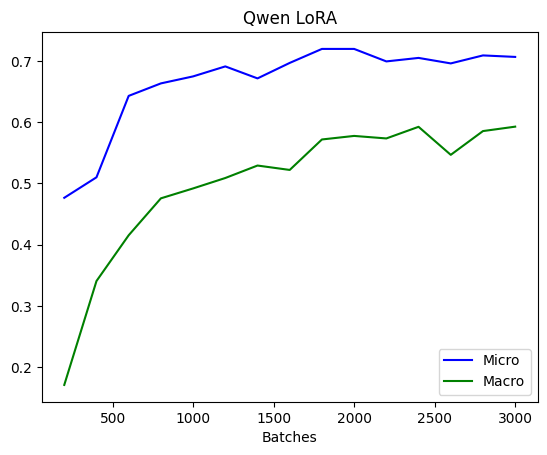

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
acc = np.array([0.476346, 0.509788, 0.642741, 0.663132, 0.674551, 0.690865, 0.671289, 0.696574, 0.719413, 0.719413, 0.699021, 0.704731, 0.695759, 0.708809, 0.706362])
f1 = np.array([0.170808, 0.340419, 0.415156, 0.475456, 0.491639, 0.508660, 0.529001, 0.521824, 0.571570, 0.577361, 0.573254, 0.592231, 0.546481, 0.585280, 0.592500])
ex = np.array([200*x for x in range(1, len(acc)+1)])

plt.plot(ex, acc, 'b', label='Micro')
plt.plot(ex, f1, 'g', label='Macro')

plt.title("Qwen LoRA")
plt.xlabel("Batches")

plt.legend(loc='lower right')

plt.show()